In [820]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [821]:
#linear Regression

weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [822]:
#test train
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [823]:
X_test

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

In [824]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

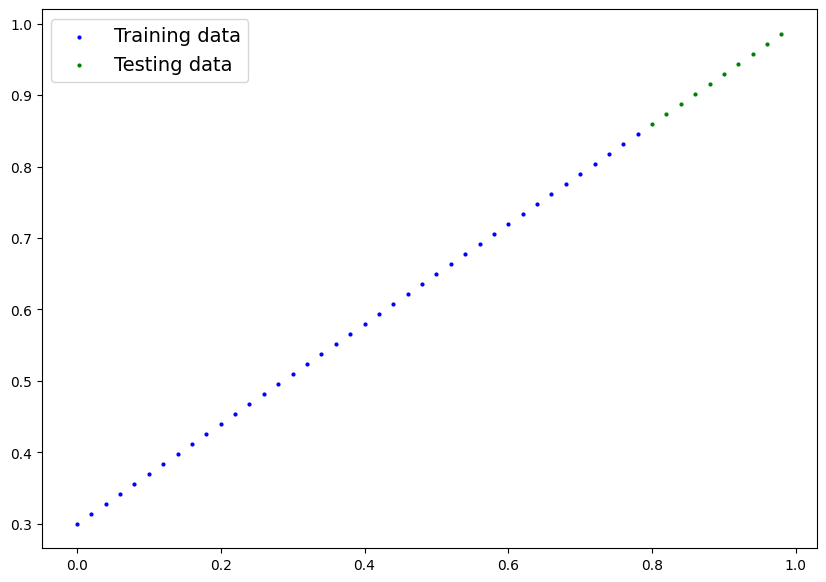

In [825]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})
  
plot_predictions()

In [826]:
#Build linear regression model

class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias   

In [827]:
torch.manual_seed(42)

model_0 = LinearRegression()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [828]:
#Make predictions with model
with torch.inference_mode():
    y_pred = model_0(X_test)
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

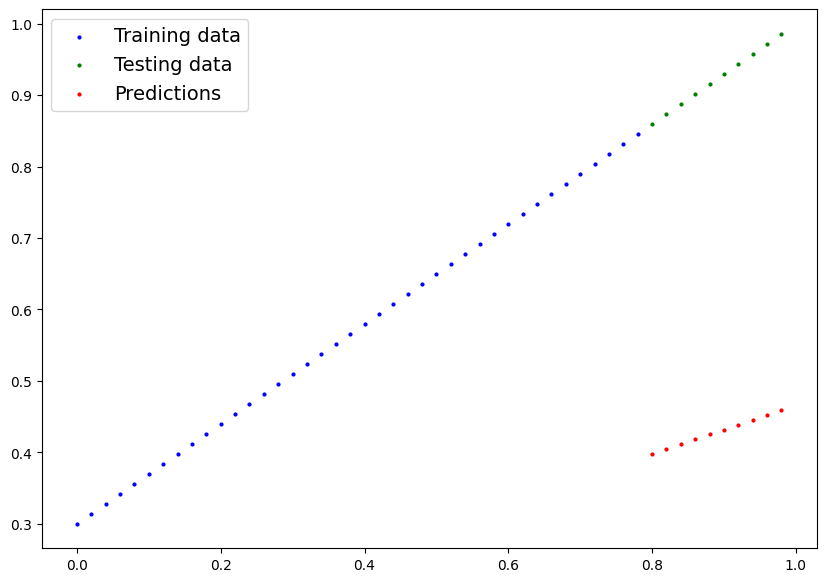

In [829]:
plot_predictions(predictions=y_pred)

In [830]:
#Set up loss function
loss_fn = torch.nn.L1Loss()

#Setup optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr = 0.01)



### PyTorch training loop
For the training loop, we'll build the following steps:

| Number | Step name | What does it do? | Code example |
| ----- | ----- | ----- | ----- |
| 1 | Forward pass | The model goes through all of the training data once, performing its `forward()` function calculations. | `model(x_train)` |
| 2 | Calculate the loss | The model's outputs (predictions) are compared to the ground truth and evaluated to see how wrong they are. | `loss = loss_fn(y_pred, y_train)` | 
| 3 | Zero gradients | The optimizers gradients are set to zero (they are accumulated by default) so they can be recalculated for the specific training step. | `optimizer.zero_grad()` |
| 4 | Perform backpropagation on the loss | Computes the gradient of the loss with respect for every model parameter to be updated  (each parameter with `requires_grad=True`). This is known as **backpropagation**, hence "backwards".  | `loss.backward()` |
| 5 | Update the optimizer (**gradient descent**) | Update the parameters with `requires_grad=True` with respect to the loss gradients in order to improve them. | `optimizer.step()` |

![pytorch training loop annotated](https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-training-loop-annotated.png)

> **Note:** The above is just one example of how the steps could be ordered or described. With experience you'll find making PyTorch training loops can be quite flexible.
>
> And on the ordering of things, the above is a good default order but you may see slightly different orders. Some rules of thumb: 
> * Calculate the loss (`loss = ...`) *before* performing backpropagation on it (`loss.backward()`).
> * Zero gradients (`optimizer.zero_grad()`) *before* computing the gradients of the loss with respect to every model parameter (`loss.backward()`).
> * Step the optimizer (`optimizer.step()`) *after* performing backpropagation on the loss (`loss.backward()`).

For resources to help understand what's happening behind the scenes with backpropagation and gradient descent, see the extra-curriculum section.


In [831]:
#Building training loop and testing loop
torch.manual_seed(42)

epochs = 200

epoch_count = []
loss_values = []
test_loss_values = []

#Loop through data
for epoch in range(epochs):
    #Set a training mode
    model_0.train()
    
    #Forward pass
    y_pred = model_0(X_train)
    
    #Calculate loss
    loss = loss_fn(y_pred, y_train)
    print(f'Loss: {loss}')
    
    #Optimizer
    optimizer.zero_grad()
    
    #Backpropagation
    loss.backward()
    
    #Step the optimizer
    optimizer.step()
    
    
    
     
    #Testing
    model_0.eval()
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)
        
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f'Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}')
        print(model_0.state_dict())

Loss: 0.31288135051727295
Epoch: 0 | Loss: 0.31288135051727295 | Test loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Loss: 0.3013603687286377
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713389158249
Epoch: 10 | Loss: 0.1976713389158249 | Test loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Loss: 0.18615034222602844
Loss: 0.1746293157339096
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912162065506
Loss: 0.09681284427642822
Loss: 0.08908725529909134
Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.2172965705394745
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Loss: 0.08227582275867462
Loss: 0.

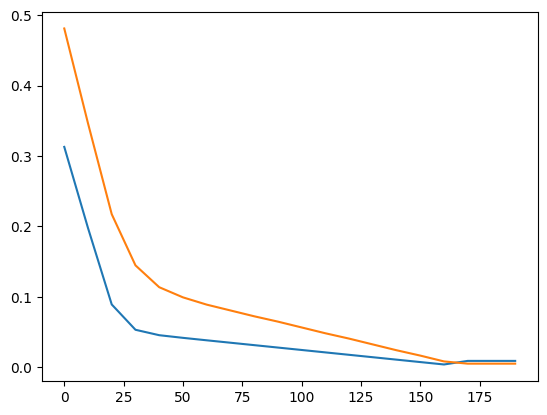

In [832]:
#Plot loss. Plt work with numpy, need to convert tensor to numpy
import numpy as np
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label = 'Train loss')
plt.plot(epoch_count, test_loss_values, label = 'Test loss')

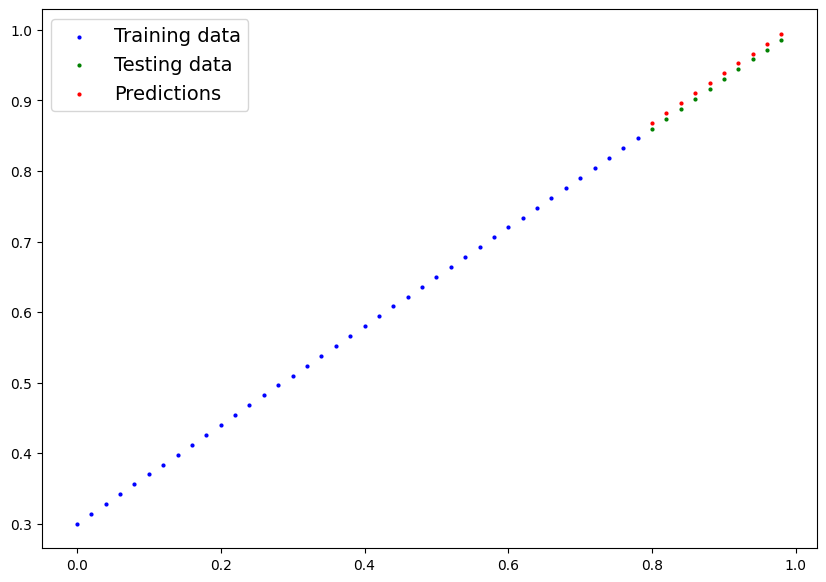

In [833]:
plot_predictions(predictions=test_pred)

In [834]:
#Saving model
from pathlib import Path

#Create model directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'LinearRegression.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f'Model saved to: {MODEL_PATH}')
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Model saved to: models


In [835]:
#Load model
loaded_model_0 = LinearRegression()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [836]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [837]:
#Predictions with loaded model

loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_pred = loaded_model_0(X_test)
loaded_model_pred

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

Summary

In [838]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [839]:
#Create device-agnostic code
device = "mps" if torch.mps.is_available() else 'cpu'
print(f'Device is {device}')

Device is mps


In [840]:
#Dummy data
weight = 0.8
bias = 0.2

#Create range values
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.2000],
         [0.2160],
         [0.2320],
         [0.2480],
         [0.2640],
         [0.2800],
         [0.2960],
         [0.3120],
         [0.3280],
         [0.3440]]))

In [841]:
#Split data (train test split)
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

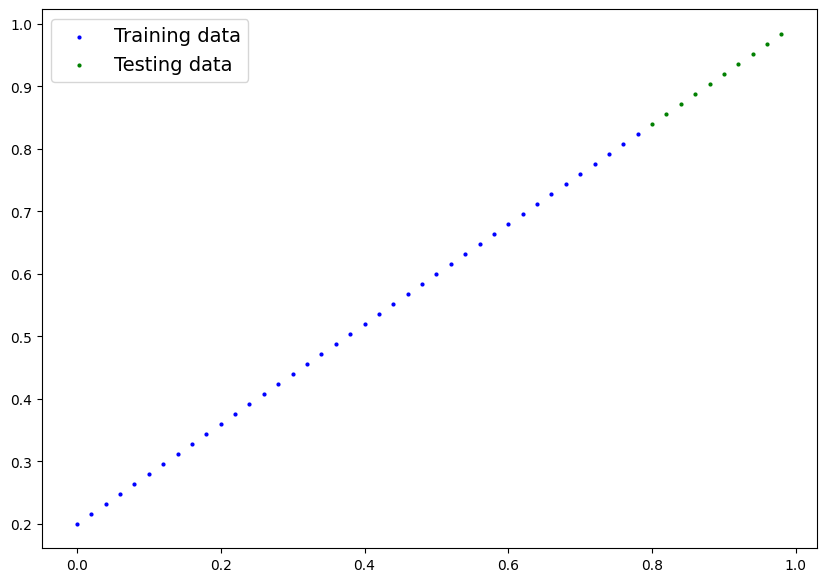

In [842]:
#Plot data

plot_predictions(X_train, y_train, X_test, y_test)

In [843]:
#Build linear model

class LinearRegressionV2(nn.Module):
    def __init__(self):
        super().__init__()
        #Use nn.Linear() 
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
torch.manual_seed(42)
model_1 = LinearRegressionV2()
model_1, model_1.state_dict()

(LinearRegressionV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [844]:
#Set up model for mps
model_1.to(device)
next(model_1.parameters()).device

device(type='mps', index=0)

In [845]:
#Training code (loss function and optimizer)
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(lr=0.01, params=model_1.parameters())

In [846]:
#Training loop

torch.manual_seed(42)

epochs = 200

#Put data on target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):
    model_1.train()
    
    #Forward pass
    y_pred = model_1(X_train)
    
    #Calcualte loss
    loss = loss_fn(y_pred, y_train)
    
    #Optimizer zero grad
    optimizer.zero_grad()
    
    #Back propagation
    loss.backward()
    
    #Optimizer step
    optimizer.step()
    
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        
        test_loss = loss_fn(test_pred, y_test)
        
    #Print
    if epoch % 10 == 0:
        print(f'Epoch {epoch} | Loss: {loss} | Test loss: {test_loss}')

Epoch 0 | Loss: 0.6161779761314392 | Test loss: 0.5849761962890625
Epoch 10 | Loss: 0.5009680986404419 | Test loss: 0.45026636123657227
Epoch 20 | Loss: 0.3857581913471222 | Test loss: 0.3155565559864044
Epoch 30 | Loss: 0.2705483138561249 | Test loss: 0.18084672093391418
Epoch 40 | Loss: 0.15533845126628876 | Test loss: 0.04613689333200455
Epoch 50 | Loss: 0.05875825881958008 | Test loss: 0.06886560469865799
Epoch 60 | Loss: 0.04580378159880638 | Test loss: 0.09473041445016861
Epoch 70 | Loss: 0.04181947931647301 | Test loss: 0.09405827522277832
Epoch 80 | Loss: 0.03831038996577263 | Test loss: 0.08853325992822647
Epoch 90 | Loss: 0.03487953543663025 | Test loss: 0.08094760030508041
Epoch 100 | Loss: 0.03144557401537895 | Test loss: 0.07267507165670395
Epoch 110 | Loss: 0.028006771579384804 | Test loss: 0.0644025132060051
Epoch 120 | Loss: 0.024577608332037926 | Test loss: 0.056816864758729935
Epoch 130 | Loss: 0.02114195190370083 | Test loss: 0.04854437708854675
Epoch 140 | Loss: 0.0

In [847]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7987]], device='mps:0')),
             ('linear_layer.bias', tensor([0.2095], device='mps:0'))])

In [848]:
#Turn model to evaluation mode

model_1.eval()

with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8484],
        [0.8644],
        [0.8804],
        [0.8964],
        [0.9123],
        [0.9283],
        [0.9443],
        [0.9603],
        [0.9762],
        [0.9922]], device='mps:0')

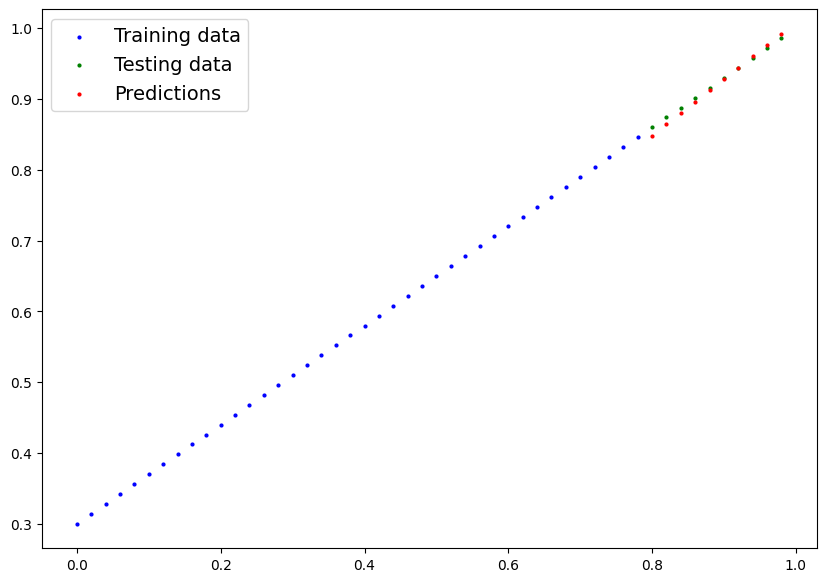

In [849]:
plot_predictions(predictions=y_preds.cpu())

In [850]:
#Save model
from pathlib import Path

MODEL_NAME = 'LinearModelV2.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#Save model state_dict
torch.save(obj = model_1.state_dict(), f = MODEL_SAVE_PATH)

In [851]:
#Load model
loaded_model_1 = LinearRegressionV2()

# Load model state dict 
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
LinearRegressionV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)
Model on device:
mps:0


In [852]:
#Evaluate model

loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='mps:0')

## Exercises

In [853]:
weight = 0.9
bias = 0.3

start = 0 
end = 1
step = 0.01

X = torch.arange(start,end, step).unsqueeze(dim=1)
y = weight * X + bias


In [854]:
train_split = int(0.8 * len(X))
X_train = X[:train_split]
y_train = y[:train_split]
X_test = X[train_split:]
y_test = y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(80, 80, 20, 20)

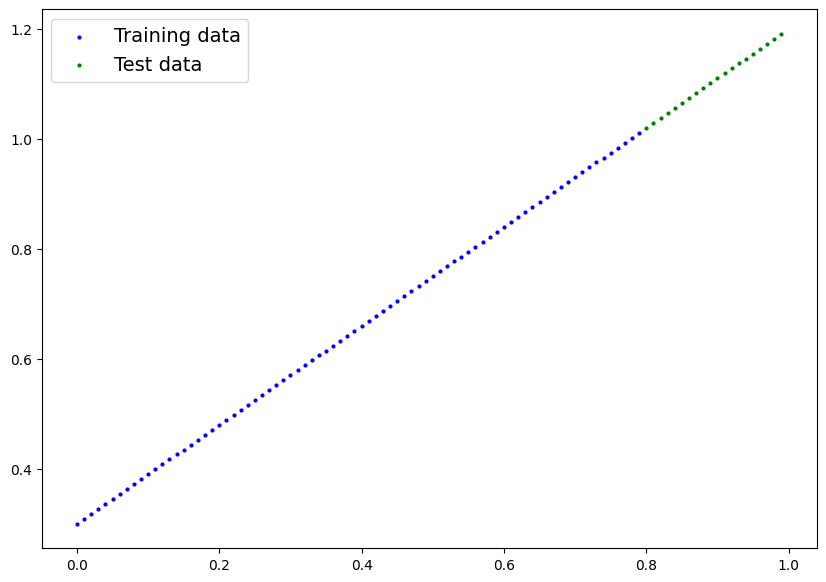

In [855]:
def plot_predictions(train_data = X_train,
                 train_labels = y_train,
                 test_data = X_test,
                 test_labels = y_test,
                 predictions = None):
  plt.figure(figsize = (10,7))
  plt.scatter(train_data,train_labels,c = 'b',s = 4,label = "Training data")
  plt.scatter(test_data,test_labels,c = 'g',s = 4,label = "Test data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c = 'r',s = 4,label = "Predictions")
  plt.legend(prop = {"size" : 14})
  
plot_predictions()

In [856]:
#MODEL

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
    
torch.manual_seed(42)
model_2 = LinearRegressionModel()
model_2, model_2.state_dict()

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [857]:
model_2.to(device)
list(model_2.parameters())

[Parameter containing:
 tensor([[0.7645]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([0.8300], device='mps:0', requires_grad=True)]

In [858]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(lr = 0.01, params= model_2.parameters())

In [859]:
torch.manual_seed(42)
epochs = 300

#Put data on target device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    model_2.train()
    
    y_pred = model_2(X_train)
    
    loss = loss_fn(y_pred, y_train)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
        
    if epoch % 20 == 0:
        model_2.eval()
        with torch.inference_mode():
            y_preds = model_2(X_test)
            test_loss = loss_fn(y_preds, y_test)
        print(f'Epoch {epoch} | Loss: {loss} | Test loss: {test_loss}')

Epoch 0 | Loss: 0.47650060057640076 | Test loss: 0.3952346742153168
Epoch 20 | Loss: 0.24529580771923065 | Test loss: 0.12452985346317291
Epoch 40 | Loss: 0.06466882675886154 | Test loss: 0.09641902893781662
Epoch 60 | Loss: 0.05159829929471016 | Test loss: 0.1160762831568718
Epoch 80 | Loss: 0.04468797519803047 | Test loss: 0.10285808145999908
Epoch 100 | Loss: 0.03783394768834114 | Test loss: 0.0875629112124443
Epoch 120 | Loss: 0.030979914590716362 | Test loss: 0.07226773351430893
Epoch 140 | Loss: 0.024127835407853127 | Test loss: 0.05628453567624092
Epoch 160 | Loss: 0.01727672852575779 | Test loss: 0.03995734453201294
Epoch 180 | Loss: 0.010425625368952751 | Test loss: 0.023630136623978615
Epoch 200 | Loss: 0.0035735485143959522 | Test loss: 0.0076469480991363525
Epoch 220 | Loss: 0.004307130817323923 | Test loss: 0.010747909545898438
Epoch 240 | Loss: 0.004307130817323923 | Test loss: 0.010747909545898438
Epoch 260 | Loss: 0.004307130817323923 | Test loss: 0.010747909545898438
E

In [860]:
model_2, model_2.state_dict()

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.8970]], device='mps:0')),
              ('linear_layer.bias', tensor([0.3055], device='mps:0'))]))

In [861]:
model_2.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_2(X_test)
y_preds

tensor([[1.0231],
        [1.0320],
        [1.0410],
        [1.0500],
        [1.0590],
        [1.0679],
        [1.0769],
        [1.0859],
        [1.0948],
        [1.1038],
        [1.1128],
        [1.1217],
        [1.1307],
        [1.1397],
        [1.1487],
        [1.1576],
        [1.1666],
        [1.1756],
        [1.1845],
        [1.1935]], device='mps:0')

In [862]:
y_preds.cpu()

tensor([[1.0231],
        [1.0320],
        [1.0410],
        [1.0500],
        [1.0590],
        [1.0679],
        [1.0769],
        [1.0859],
        [1.0948],
        [1.1038],
        [1.1128],
        [1.1217],
        [1.1307],
        [1.1397],
        [1.1487],
        [1.1576],
        [1.1666],
        [1.1756],
        [1.1845],
        [1.1935]])

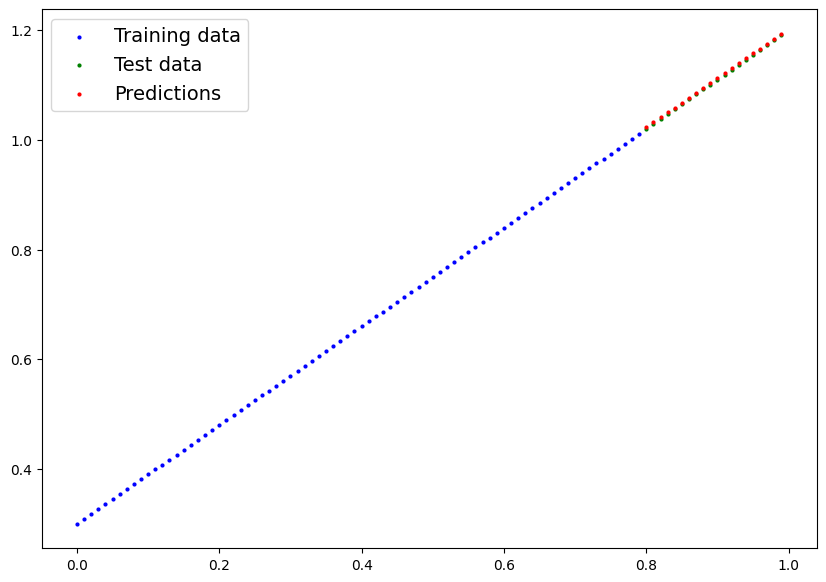

In [863]:
plot_predictions(predictions=y_preds.cpu())